<a href="https://colab.research.google.com/github/laceywang11/MSSP6070/blob/main/Final_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Data and Initial Clean**

In [2]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

Saving SuperMarket Analysis.csv to SuperMarket Analysis.csv


In [3]:
df = pd.read_csv("SuperMarket Analysis.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [5]:
new_cols = [
    "Branch", "City", "Customer type", "Gender",
    "Product line", "Unit price", "Quantity", "Tax 5%",
    "Sales", "Date", "Time", "Payment",
    "cogs", "gross margin percentage", "gross income",
    "Rating"
]

df = df[new_cols]
df.head()

,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df["Time"] = pd.to_datetime(df["Time"]).dt.time

/tmp/ipython-input-4239922235.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"]).dt.time


In [7]:
numeric_cols = [
    "Unit price", "Quantity", "Tax 5%",
    "Sales", "cogs", "gross margin percentage",
    "gross income", "Rating"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
df.isnull().sum()

,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0
Date,0


# **Descriptive Statistics**

**1. Numerical variables descriptive statistics**

In [9]:
num_cols = ["Unit price", "Quantity", "Tax 5%", "Sales",
            "cogs", "gross margin percentage", "gross income", "Rating"]

In [10]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Unit price,1000.0,55.672130,2.649463e+01,10.080000,32.875000,55.230000,77.935000,99.960000
Quantity,1000.0,5.510000,2.923431e+00,1.000000,3.000000,5.000000,8.000000,10.000000
Tax 5%,1000.0,15.379369,1.170883e+01,0.508500,5.924875,12.088000,22.445250,49.650000
Sales,1000.0,322.966749,2.458853e+02,10.678500,124.422375,253.848000,471.350250,1042.650000
cogs,1000.0,307.587380,2.341765e+02,10.170000,118.497500,241.760000,448.905000,993.000000
gross margin percentage,1000.0,4.761905,6.131498e-14,4.761905,4.761905,4.761905,4.761905,4.761905
gross income,1000.0,15.379369,1.170883e+01,0.508500,5.924875,12.088000,22.445250,49.650000
Rating,1000.0,6.972700,1.718580e+00,4.000000,5.500000,7.000000,8.500000,10.000000


In [11]:
df[num_cols].agg(["mean", "std"]).T

,mean,std
Unit price,55.672130,2.649463e+01
Quantity,5.510000,2.923431e+00
Tax 5%,15.379369,1.170883e+01
Sales,322.966749,2.458853e+02
cogs,307.587380,2.341765e+02
gross margin percentage,4.761905,6.131498e-14
gross income,15.379369,1.170883e+01
Rating,6.972700,1.718580e+00


**2. Categorical variables descriptive summary**

In [12]:
cat_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in cat_cols:
    print("\n", col)
    display(pd.DataFrame({
        "count": df[col].value_counts(),
        "proportion": df[col].value_counts(normalize=True).round(3)
    }))


 Branch


,count,proportion
Branch,,
Alex,340,0.340
Cairo,332,0.332
Giza,328,0.328



 City


,count,proportion
City,,
Yangon,340,0.340
Mandalay,332,0.332
Naypyitaw,328,0.328



 Customer type


...

,count,proportion
Gender,,
Female,571,0.571
Male,429,0.429



 Product line


,count,proportion
Product line,,
Fashion accessories,178,0.178
Food and beverages,174,0.174
Electronic accessories,170,0.170
Sports and travel,166,0.166
Home and lifestyle,160,0.160
Health and beauty,152,0.152



 Payment


,count,proportion
Payment,,
Ewallet,345,0.345
Cash,344,0.344
Credit card,311,0.311


**3. Average Sales by Different Categories**

In [13]:
#Sales by Gender
df.groupby("Gender")["Sales"].mean()

,Sales
Gender,
Female,340.931414
Male,299.055738


In [14]:
#Sales by Customer Type
df.groupby("Customer type")["Sales"].mean()

,Sales
Customer type,
Member,335.742945
Normal,306.372379


In [15]:
#Sales by Branch
df.groupby("Branch")["Sales"].mean()

,Sales
Branch,
Alex,312.354031
Cairo,319.872506
Giza,337.099715


In [16]:
#Sales by Product Line
df.groupby("Product line")["Sales"].mean().sort_values(ascending=False)

,Sales
Product line,
Home and lifestyle,336.636956
Sports and travel,332.065220
Health and beauty,323.643020
Food and beverages,322.671517
Electronic accessories,319.632538
Fashion accessories,305.089298


In [17]:
#Sales by Payment
df.groupby("Payment")["Sales"].mean()

,Sales
Payment,
Cash,326.181890
Credit card,324.009878
Ewallet,318.820600


In [18]:
#Sales by City
df.groupby("City")["Sales"].mean()

,Sales
City,
Mandalay,319.872506
Naypyitaw,337.099715
Yangon,312.354031


# **Visulizations**

**1. Average Sales by Product Line**

/tmp/ipython-input-911419953.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Product line", y="Sales", estimator="mean", ci=None, palette="Set2")
/tmp/ipython-input-911419953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Product line", y="Sales", estimator="mean", ci=None, palette="Set2")


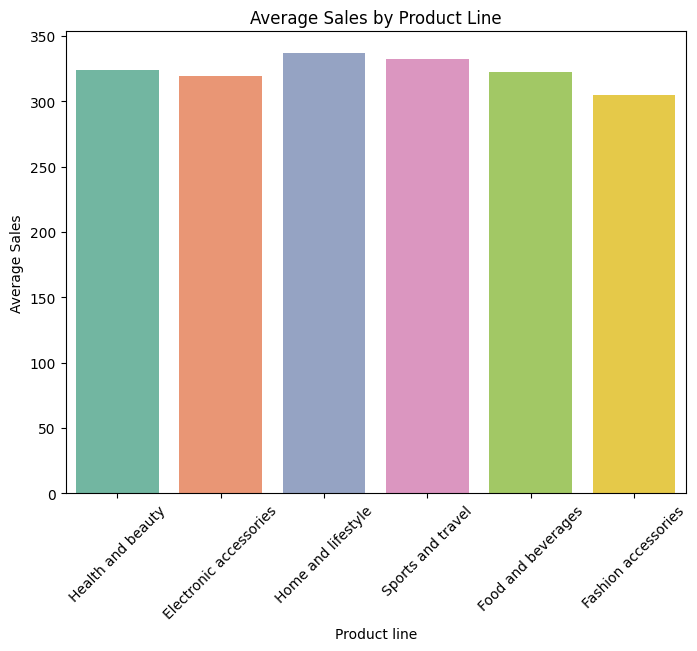

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Product line", y="Sales", estimator="mean", ci=None, palette="Set2")

plt.title("Average Sales by Product Line")
plt.xticks(rotation=45)
plt.ylabel("Average Sales")
plt.show()

/tmp/ipython-input-3024686587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Product line", y="Sales", palette="Set3")


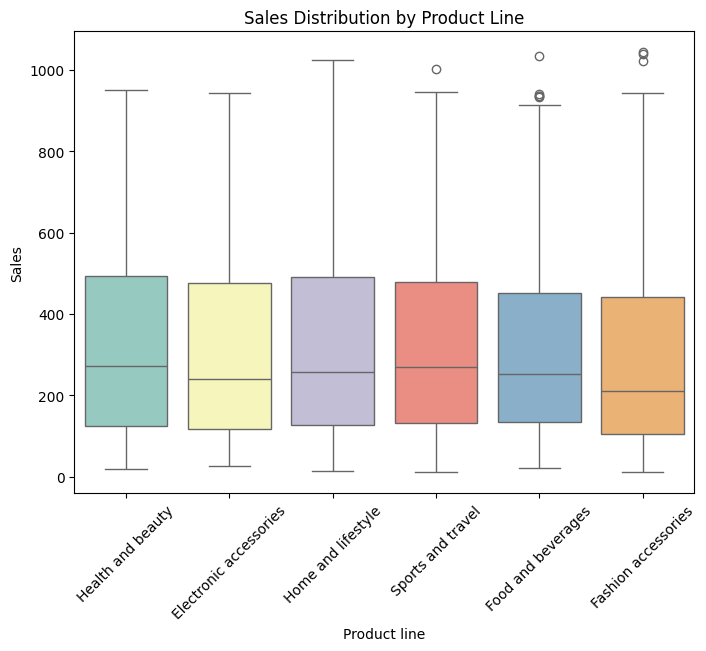

In [20]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Product line", y="Sales", palette="Set3")

plt.title("Sales Distribution by Product Line")
plt.xticks(rotation=45)
plt.ylabel("Sales")
plt.show()

1.1 Total Sales by Product Line

In [42]:
df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)


,Sales
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


/tmp/ipython-input-41153759.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Product line", y="Sales", estimator=sum, palette="viridis")


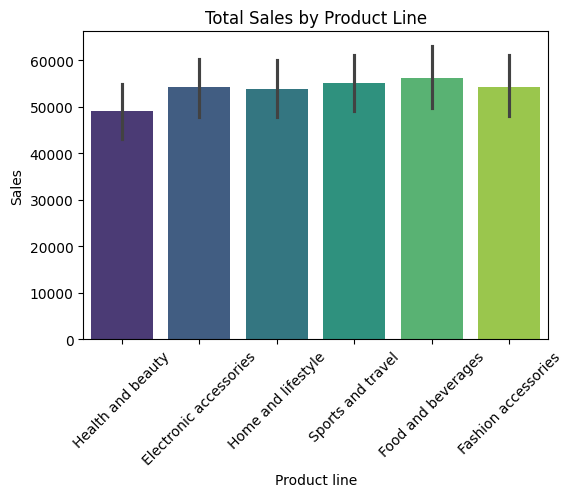

In [43]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="Product line", y="Sales", estimator=sum, palette="viridis")
plt.xticks(rotation=45)
plt.title("Total Sales by Product Line")
plt.show()


1.2 Unit Price by Product Lines

In [45]:
unit_price_summary = df.groupby("Product line")["Unit price"].agg(["mean", "median", "min", "max"]).round(2)
unit_price_summary

,mean,median,min,max
Product line,,,,
Electronic accessories,53.55,51.50,10.56,99.73
Fashion accessories,57.15,55.09,10.18,99.89
Food and beverages,56.01,54.00,10.13,99.79
Health and beauty,54.85,57.40,10.08,99.96
Home and lifestyle,55.32,55.59,10.53,99.92
Sports and travel,56.99,58.65,10.17,99.96


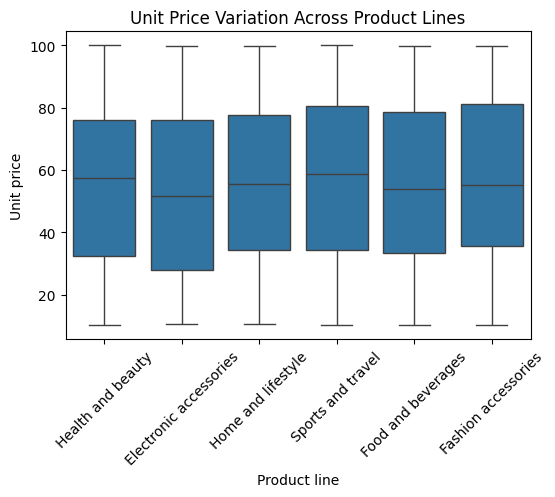

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Product line", y="Unit price")
plt.xticks(rotation=45)
plt.title("Unit Price Variation Across Product Lines")
plt.show()


**2. Average Sales by Customer Type**

/tmp/ipython-input-2952044620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Customer type", y="Sales", estimator="mean", errorbar=None, palette="Set3")


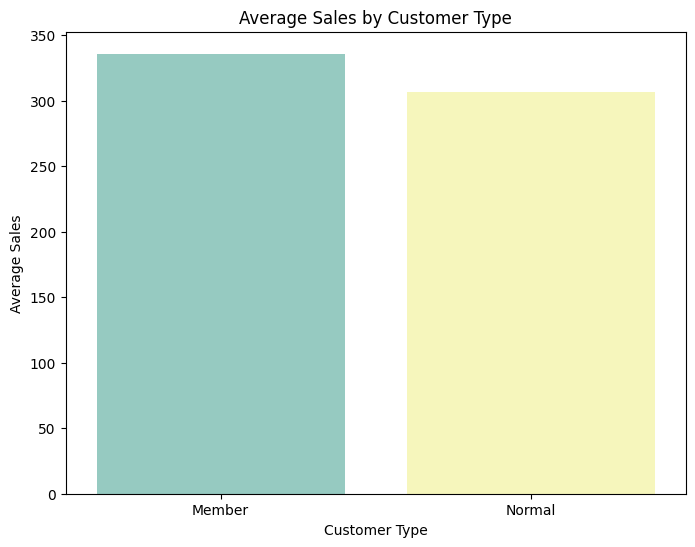

In [21]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Customer type", y="Sales", estimator="mean", errorbar=None, palette="Set3")

plt.title("Average Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales")
plt.show()

/tmp/ipython-input-422245426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


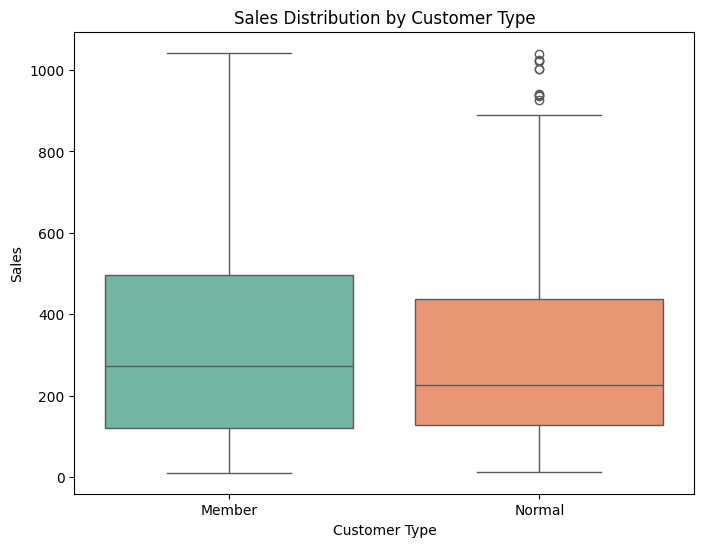

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Customer type",
    y="Sales",
    palette="Set2"
)

plt.title("Sales Distribution by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Sales")
plt.show()


**3. Average Sales by Payment Method**

/tmp/ipython-input-721578554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


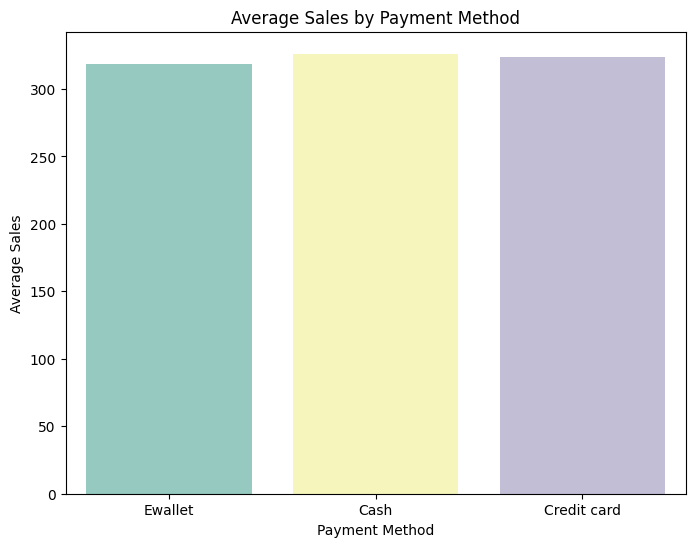

In [23]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df,
    x="Payment",
    y="Sales",
    estimator="mean",
    errorbar=None,
    palette="Set3"
)

plt.title("Average Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Sales")
plt.show()


/tmp/ipython-input-3724232277.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


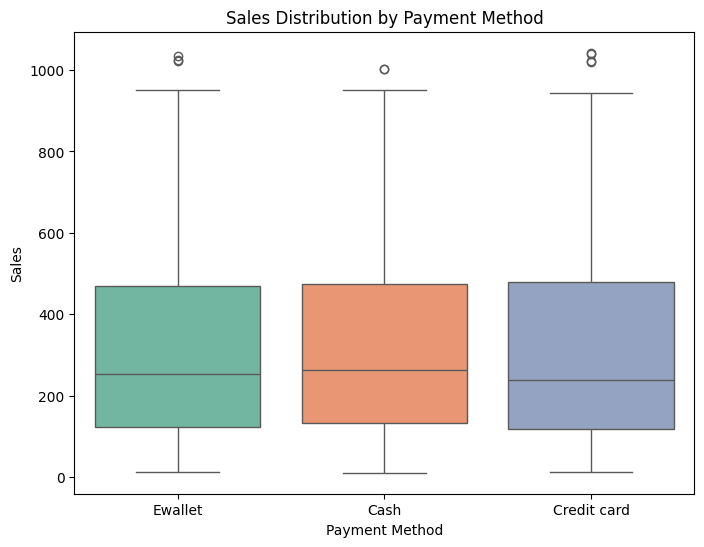

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Payment",
    y="Sales",
    palette="Set2"
)

plt.title("Sales Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Sales")
plt.show()


# **Distribution Check**

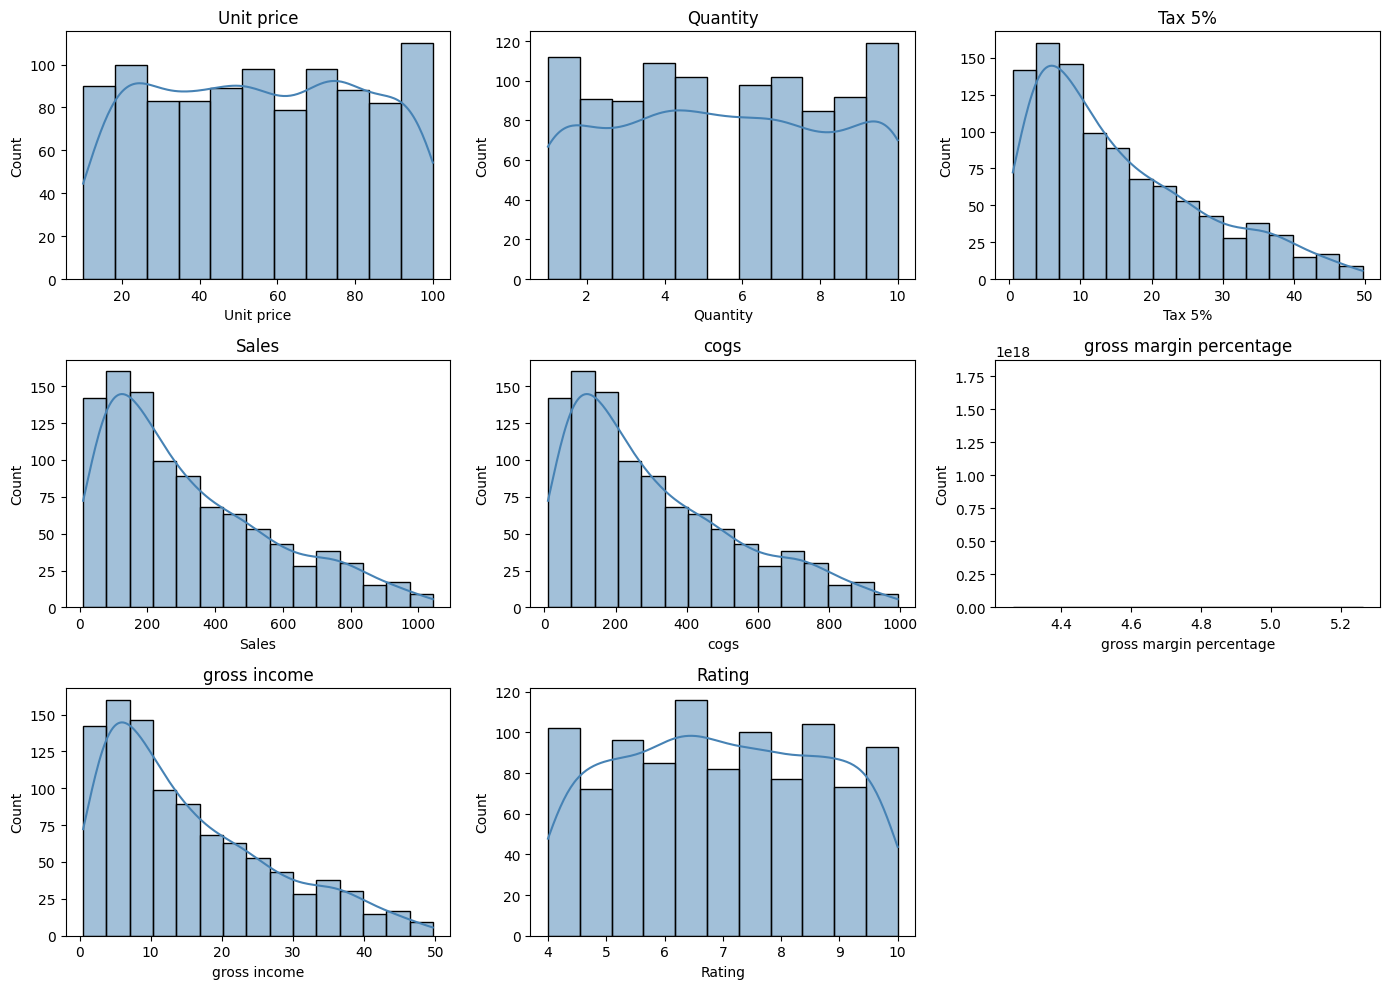

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color="steelblue")
    plt.title(col)

plt.tight_layout()
plt.show()


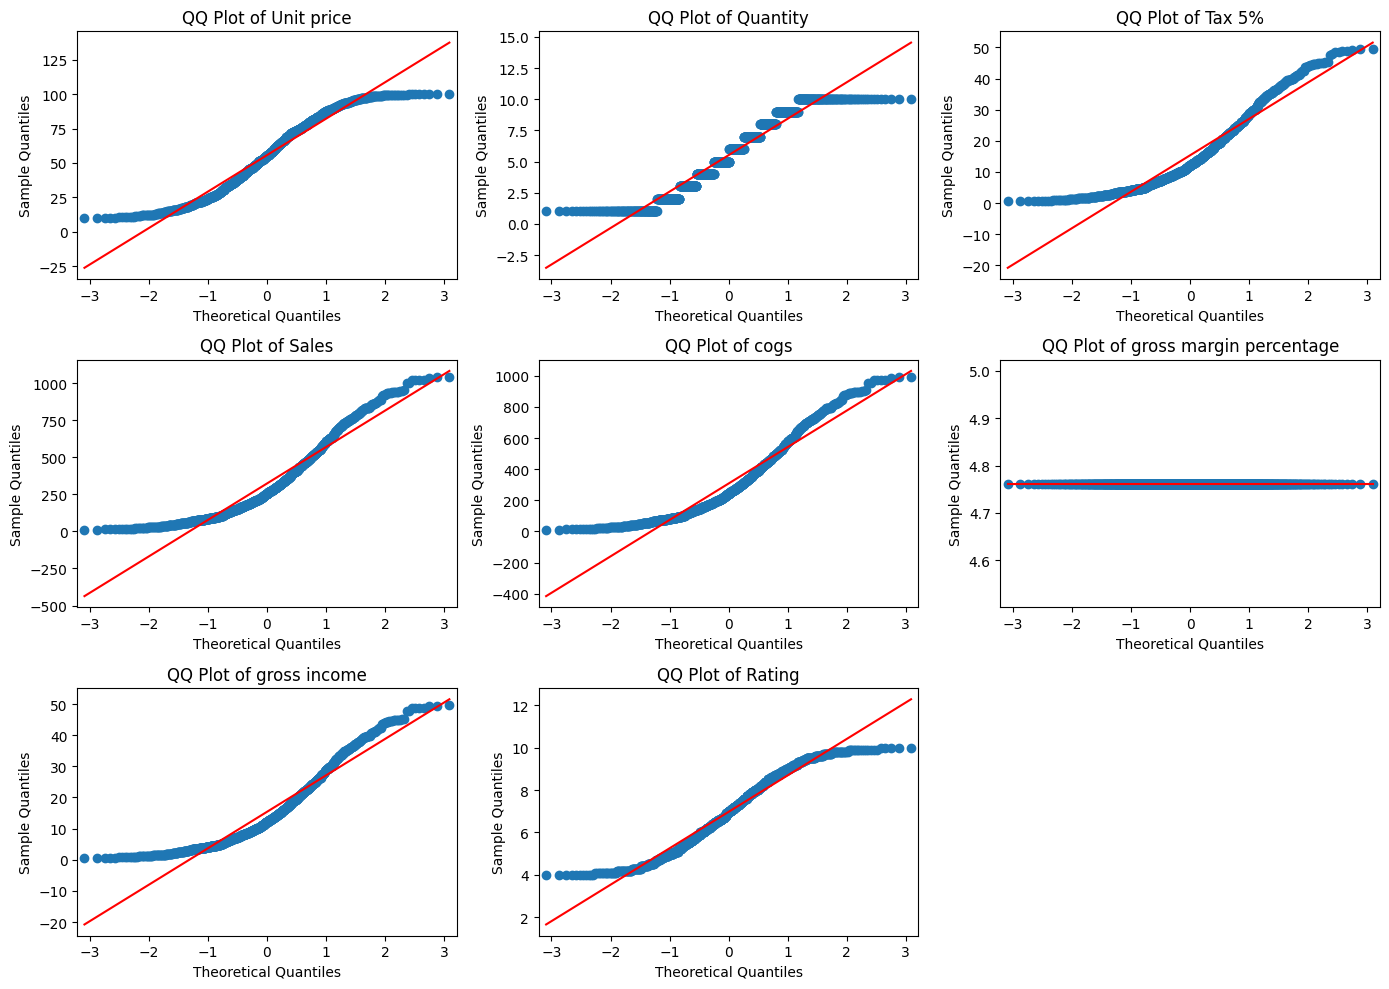

In [26]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.figure(figsize=(14,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sm.qqplot(df[col], line='s', ax=plt.gca())
    plt.title(f"QQ Plot of {col}")

plt.tight_layout()
plt.show()

# **Detect Outliers and Handling**

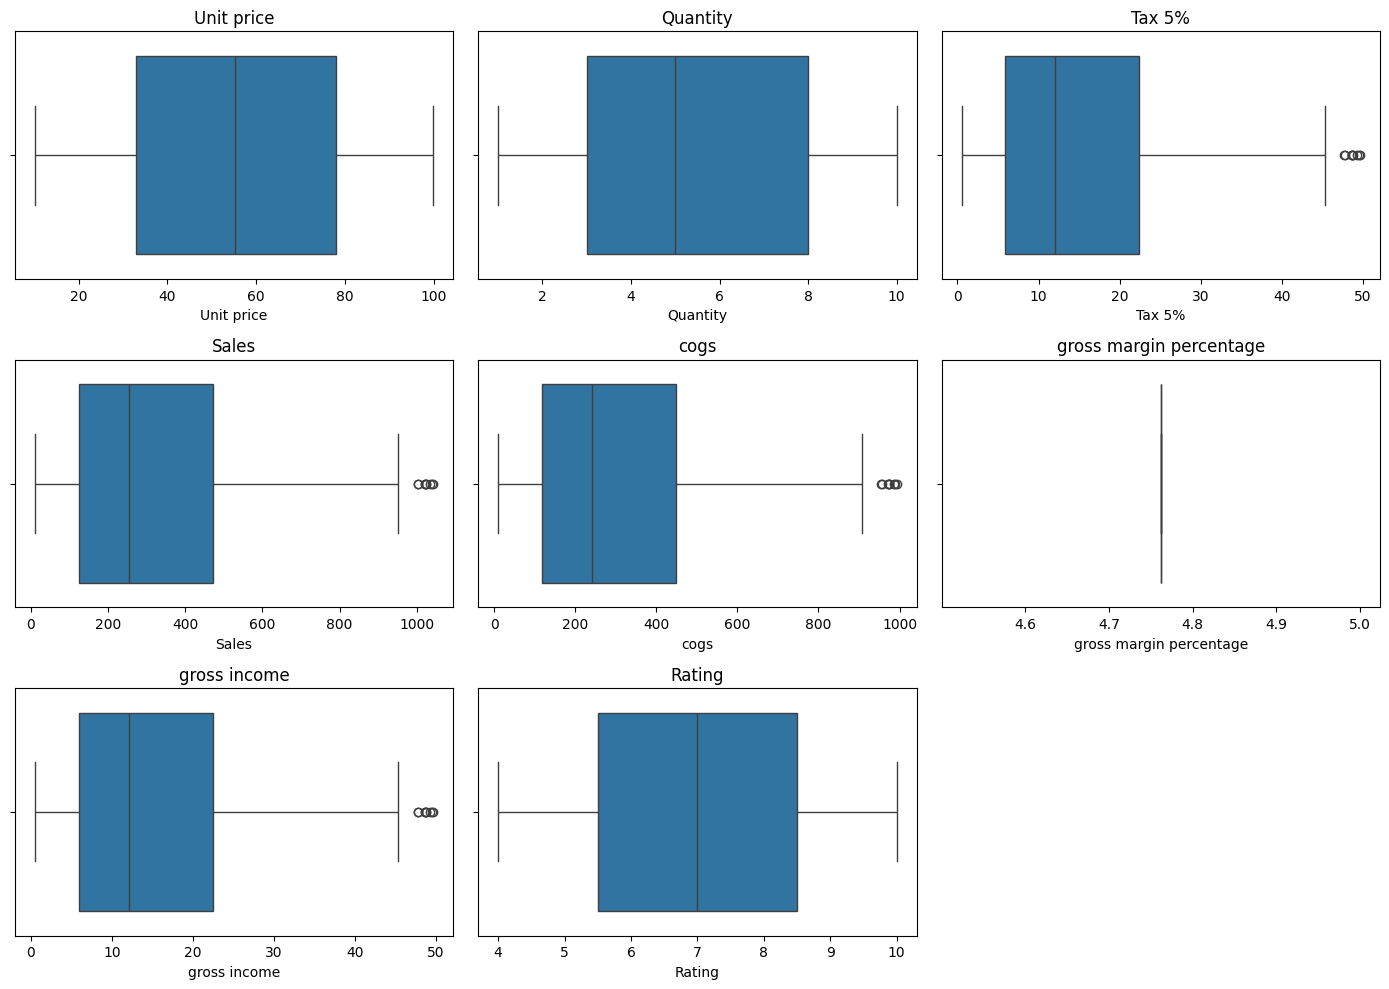

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


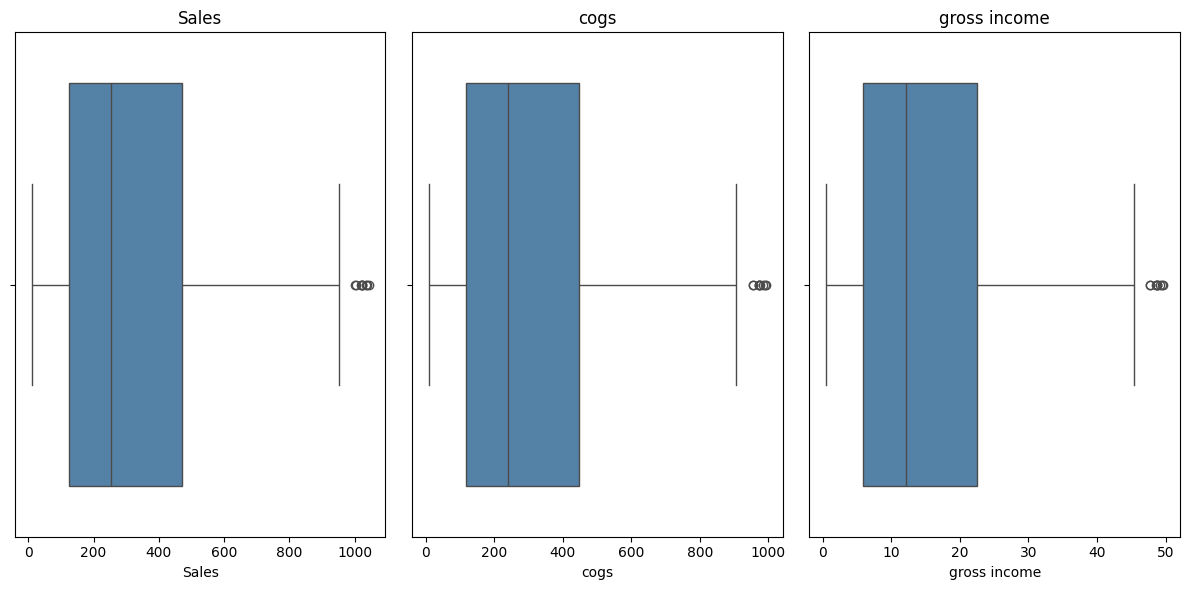

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = ["Sales", "cogs", "gross income"]

plt.figure(figsize=(12, 6))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col], color="steelblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [28]:
log_vars = ["Sales", "cogs", "gross income", "Tax 5%"]

df["log_Sales"] = np.log(df["Sales"] + 1)
df["log_cogs"] = np.log(df["cogs"] + 1)
df["log_gross_income"] = np.log(df["gross income"] + 1)
df["log_Tax"] = np.log(df["Tax 5%"] + 1)

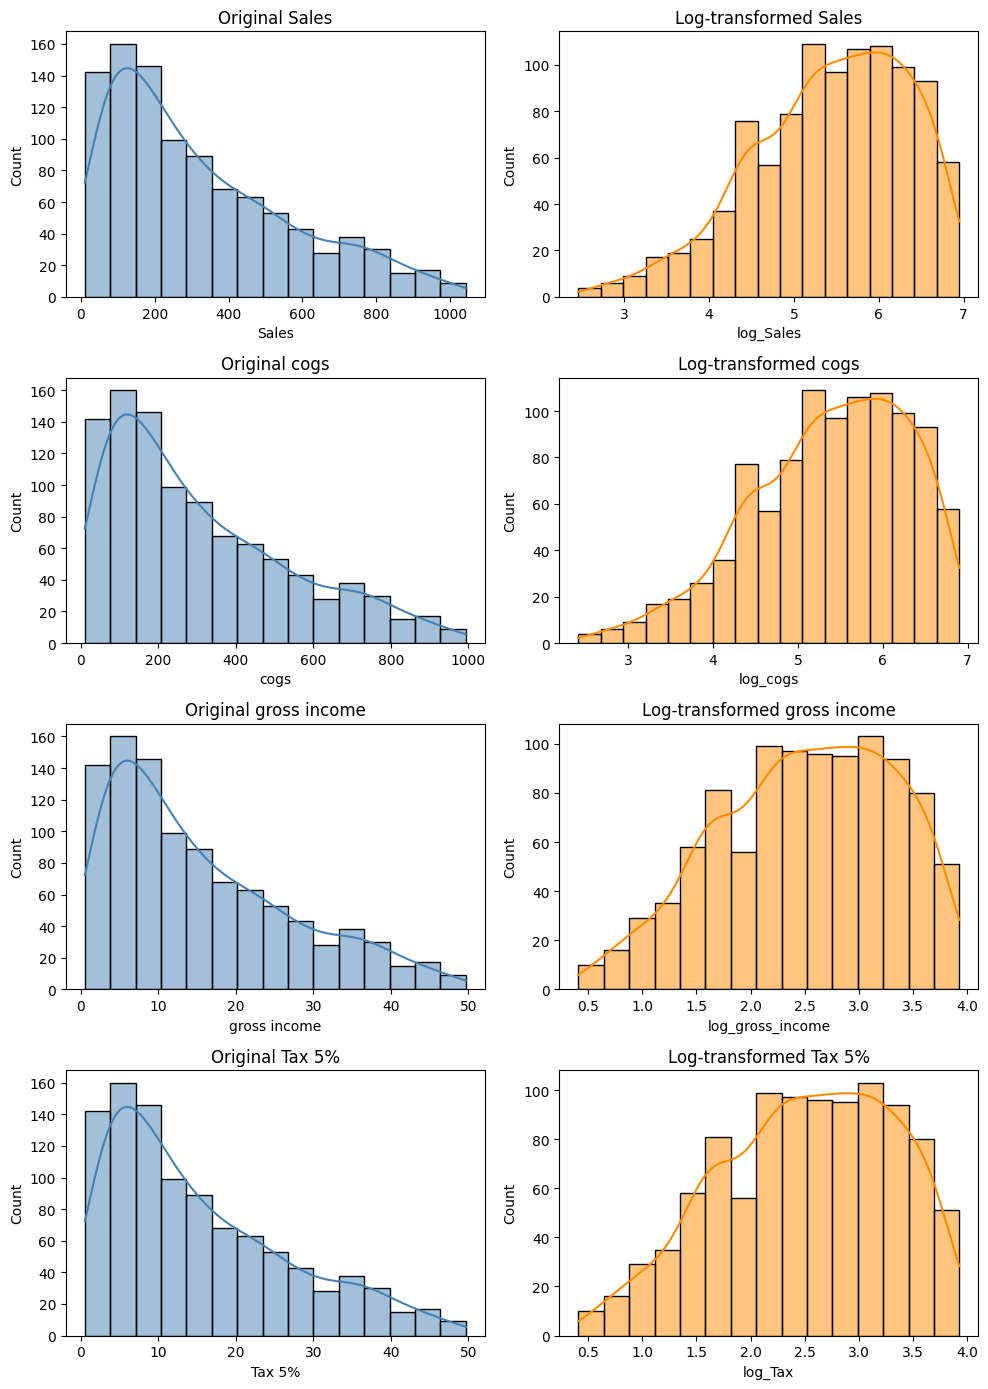

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

orig_cols = ["Sales", "cogs", "gross income", "Tax 5%"]
log_cols  = ["log_Sales", "log_cogs", "log_gross_income", "log_Tax"]

fig, axes = plt.subplots(4, 2, figsize=(10, 14))

for i, (orig, logc) in enumerate(zip(orig_cols, log_cols)):

    # original
    sns.histplot(df[orig], kde=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"Original {orig}")

    # log-transformed
    sns.histplot(df[logc], kde=True, ax=axes[i, 1], color="darkorange")
    axes[i, 1].set_title(f"Log-transformed {orig}")

plt.tight_layout()
plt.show()

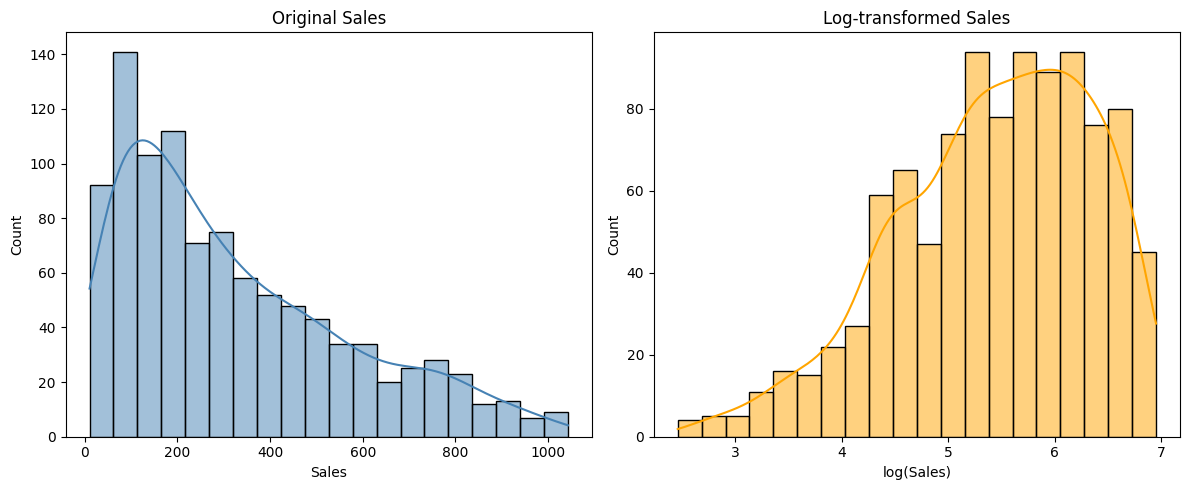

In [32]:
col = "Sales"

df["log_" + col] = np.log1p(df[col])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df[col], kde=True, bins=20, color="steelblue")
plt.title(f"Original {col}")
plt.xlabel(col)

plt.subplot(1,2,2)
sns.histplot(df["log_" + col], kde=True, bins=20, color="orange")
plt.title(f"Log-transformed {col}")
plt.xlabel("log(" + col + ")")

plt.tight_layout()
plt.show()


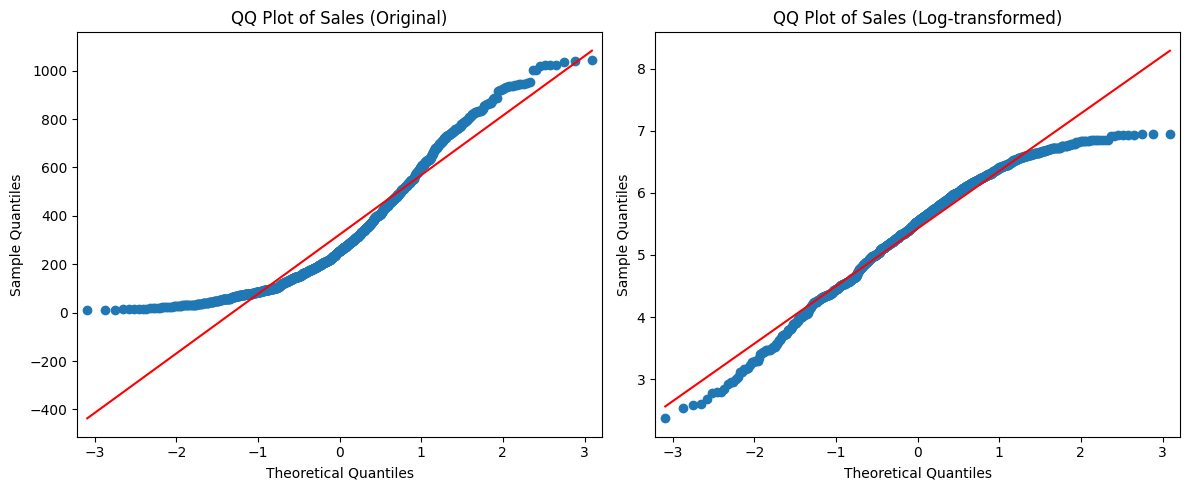

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
sm.qqplot(df["Sales"], line='s', ax=plt.gca())
plt.title("QQ Plot of Sales (Original)")

# Log-transformed
plt.subplot(1,2,2)
sm.qqplot(np.log(df["Sales"] + 1e-6), line='s', ax=plt.gca())
plt.title("QQ Plot of Sales (Log-transformed)")

plt.tight_layout()
plt.show()


# **Correlation and Other Findings**

In [33]:
num_cols = ["Unit price", "Quantity", "Tax 5%", "Sales",
            "cogs", "gross margin percentage", "gross income", "Rating"]

df[num_cols].corr()["Sales"].sort_values(ascending=False)

,Sales
Sales,1.000000
gross income,1.000000
Tax 5%,1.000000
cogs,1.000000
Quantity,0.705510
Unit price,0.633962
Rating,-0.036442
gross margin percentage,NaN


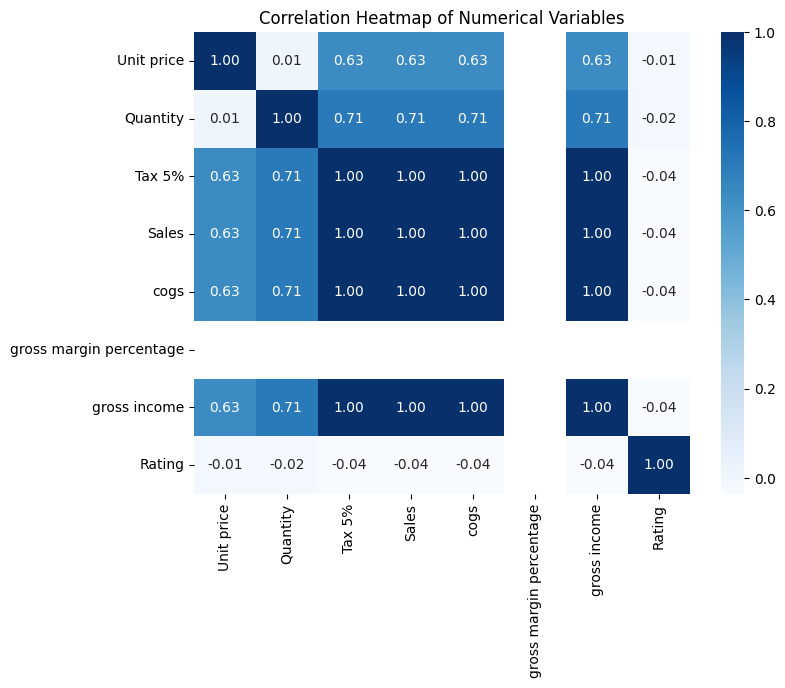

In [34]:
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

**Other findings**

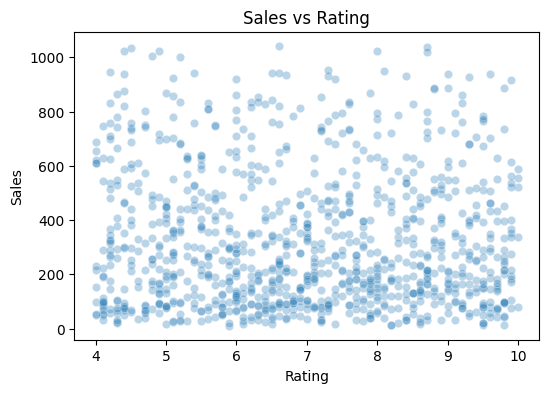

In [35]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Rating", y="Sales", alpha=0.3)
plt.title("Sales vs Rating")
plt.show()


In [46]:
df.groupby("City")["Sales"].mean().round(2)

,Sales
City,
Mandalay,319.87
Naypyitaw,337.10
Yangon,312.35


<Axes: xlabel='City', ylabel='Sales'>

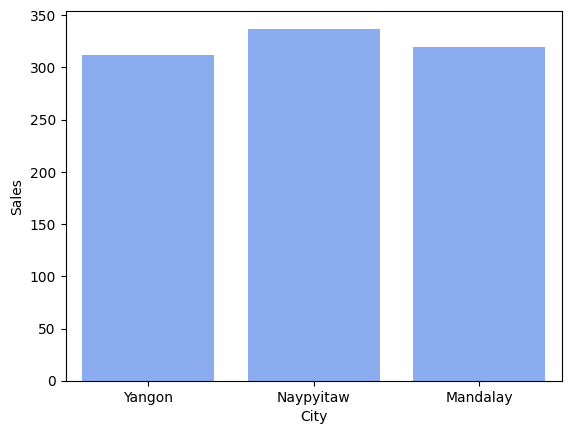

In [36]:
sns.barplot(data=df, x="City", y="Sales", estimator="mean", color="#7AA7FF", errorbar=None)


In [44]:
df.groupby("TimePeriod")["Sales"].mean()

/tmp/ipython-input-1948253405.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("TimePeriod")["Sales"].mean()


,Sales
TimePeriod,
Morning,323.553982
Afternoon,326.042600
Evening,318.717177


/tmp/ipython-input-1251183091.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="TimePeriod", y="Sales", palette=["#8ECFC9", "#FFBE7A", "#FA7F6F"])


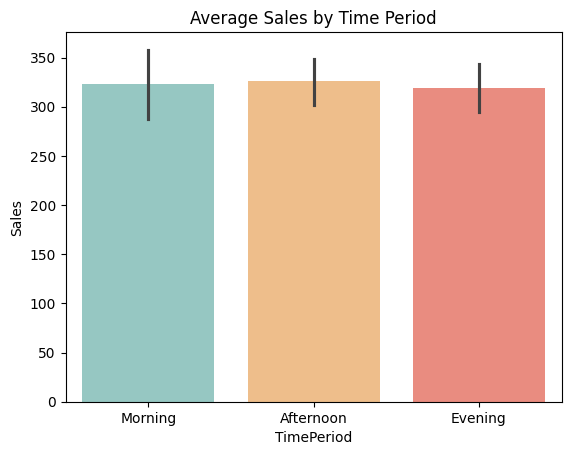

In [37]:
df["Hour"] = df["Time"].apply(lambda x: x.hour)

df["TimePeriod"] = pd.cut(df["Hour"],
                          bins=[0, 12, 17, 24],
                          labels=["Morning", "Afternoon", "Evening"],
                          right=False)

sns.barplot(data=df, x="TimePeriod", y="Sales", palette=["#8ECFC9", "#FFBE7A", "#FA7F6F"])
plt.title("Average Sales by Time Period")
plt.show()

In [47]:
hourly_sales = df.groupby("Hour")["Sales"].mean().round(2)
hourly_sales

,Sales
Hour,
10,311.10
11,337.53
12,292.88
13,337.12
14,371.43
15,305.68
16,327.61
17,330.34
18,279.90


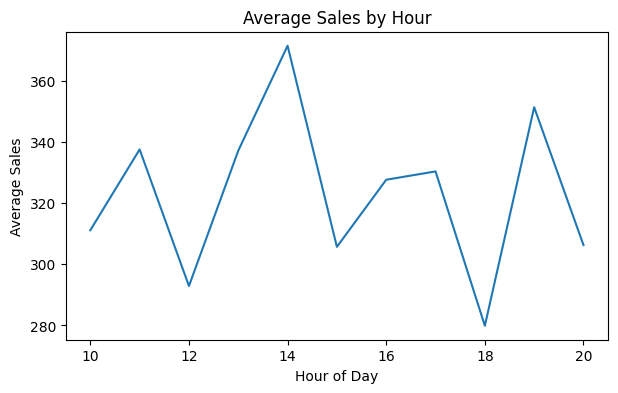

In [41]:
hourly_sales = df.groupby("Hour")["Sales"].mean()

plt.figure(figsize=(7,4))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values)
plt.title("Average Sales by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Sales")
plt.show()
